In [1]:
import pandas as pd
import numpy as np

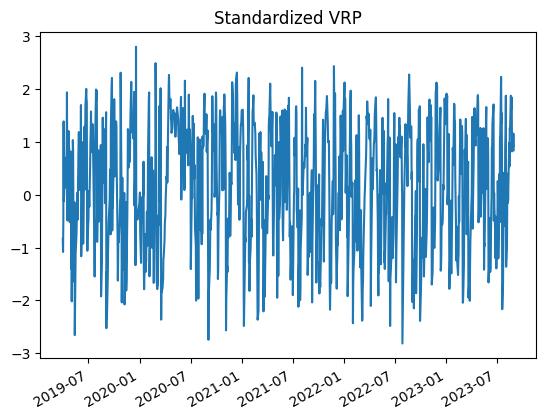

Sharpe Ratio: -2.95
Maximum Drawdown: -39.88
CAGR: -0.01%


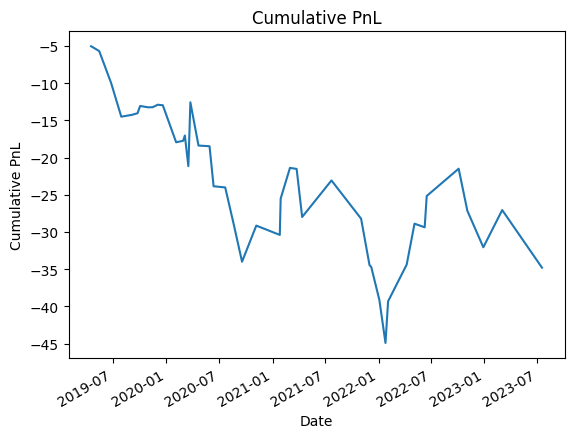

Optimized Upper Threshold: 2.5
Optimized Lower Threshold: -1.6801239392051692
After Optimization:
Sharpe Ratio: 18.95
Maximum Drawdown: -0.25
CAGR: 0.01%


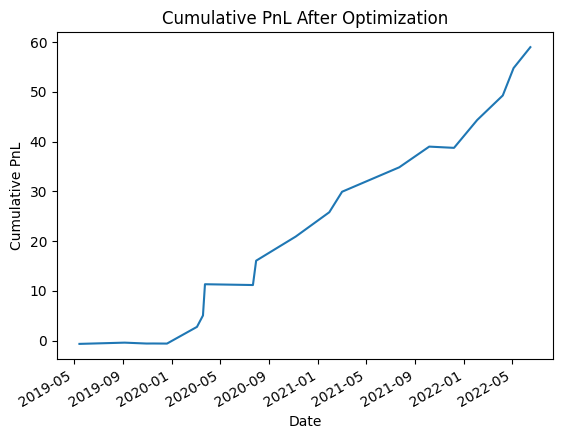

In [2]:
# Import Necessary Libraries
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from skopt import gp_minimize

# Helper Functions
def myround(x, base=5):
    return base * round(x / base)

def rolling_z_score(series, window):
    mean = series.rolling(window).mean()
    std = series.rolling(window).std()
    z_score = (series - mean) / std
    return z_score

# Option Classes
class Option:
    def __init__(self, strike: float, premium: float, expiry: pd.Timestamp):
        self.strike = strike
        self.premium = premium
        self.expiry = expiry
        self.spot_price = None

    def insert_spot(self, spot_price: float):
        self.spot_price = spot_price

    def payoff(self, option_type: str, position: str):
        """
        Calculate the payoff of the option.

        Parameters:
        - option_type: 'call' or 'put'
        - position: 'long' or 'short'

        Returns:
        - Payoff of the option position.
        """
        if self.spot_price is None:
            raise ValueError("Spot price not set. Call insert_spot() first.")

        if option_type == 'call':
            intrinsic_value = max(0, self.spot_price - self.strike)
        elif option_type == 'put':
            intrinsic_value = max(0, self.strike - self.spot_price)
        else:
            raise ValueError("Invalid option type. Must be 'call' or 'put'.")

        if position == 'long':
            return intrinsic_value - self.premium
        elif position == 'short':
            return self.premium - intrinsic_value
        else:
            raise ValueError("Invalid position. Must be 'long' or 'short'.")

class IronCondor:
    def __init__(self, direction: str, strikes: dict, premiums: dict, expiry: pd.Timestamp):
        """
        Initialize the Iron Condor strategy.

        Parameters:
        - direction: 'long' or 'short' Iron Condor.
        - strikes: Dictionary with keys 'strike1', 'strike2', 'strike3', 'strike4'.
        - premiums: Dictionary with keys 'premium1', 'premium2', 'premium3', 'premium4'.
        - expiry: Expiration date of the options (pd.Timestamp).
        """
        self.direction = direction
        self.expiry = expiry

        # Initialize option positions
        self.options = {
            'short_put': Option(strikes['strike1'], premiums['premium1'], expiry),
            'long_put': Option(strikes['strike2'], premiums['premium2'], expiry),
            'long_call': Option(strikes['strike3'], premiums['premium3'], expiry),
            'short_call': Option(strikes['strike4'], premiums['premium4'], expiry),
        }

    def initial_cashflow(self):
        """
        Calculate the initial cashflow of the Iron Condor strategy.

        Returns:
        - Initial cashflow (float).
        """
        cashflow = 0
        for position, option in self.options.items():
            if 'short' in position:
                cashflow += option.premium
            else:
                cashflow -= option.premium
        return cashflow if self.direction == 'short' else -cashflow

    def insert_spot(self, spot_price: float):
        """
        Insert the spot price at expiry for all options.

        Parameters:
        - spot_price: Spot price at expiry (float).
        """
        for option in self.options.values():
            option.insert_spot(spot_price)

    def payoff(self):
        """
        Calculate the total payoff of the Iron Condor strategy at expiry.

        Returns:
        - Total payoff (float).
        """
        total_payoff = 0
        for position, option in self.options.items():
            option_type = 'call' if 'call' in position else 'put'
            pos = 'short' if 'short' in position else 'long'
            payoff = option.payoff(option_type, pos)
            total_payoff += payoff
        return total_payoff if self.direction == 'short' else -total_payoff

# Data Loading and Preparation
# Load options data
xlu_options = pd.read_hdf("data/etf_options_data.hf5", key="XLU")
xlu_options.set_index("date", inplace=True)
xlu_options["strike_price"] = xlu_options["strike_price"] / 1000

# Load predicted volatility and implied volatility
xlu_pred = pd.read_csv("data/xlu_pred.csv", parse_dates=True, index_col=0)
xlu_pred.rename(columns={"0": "Rolling Pred"}, inplace=True)
xlu_iv = pd.read_csv("data/XLU_IV.csv", parse_dates=True, index_col=0)

# Prepare VRP Data
# Calculate Volatility Risk Premia (VRP)
xlu_vrp = (xlu_iv["Average IV"] - xlu_pred["Rolling Pred"]).dropna()
xlu_vrp_standardised = rolling_z_score(xlu_vrp, window=10)

# Plot VRP
xlu_vrp_standardised.plot(title='Standardized VRP')
plt.show()

# Filter Options Data
# Filter options with the nearest expiration date
xlu_filtered_options = xlu_options.groupby("date").apply(
    lambda x: x[x["exdate"] == x["exdate"].min()]
).reset_index(level=0, drop=True)

# Add weekday information
xlu_filtered_options["day"] = xlu_filtered_options.index.weekday
xlu_filtered_options["ex_day"] = xlu_filtered_options["exdate"].dt.weekday

# Load Time Series Data
# Load ETF time series data
xlu_time_series = pd.read_hdf("data/etf_series.hf5", key="XLU")
xlu_time_series["day"] = xlu_time_series.index.weekday
xlu_time_series["vrp"] = xlu_vrp_standardised

# Generate Trading Signals
# Define Thresholds
upper_threshold = 1.75
lower_threshold = -1.75

# Create Signals
def generate_signals(df, upper_threshold, lower_threshold):
    df["signal"] = np.where(
        df["vrp"] > upper_threshold, 1,
        np.where(df["vrp"] < lower_threshold, -1, 0)
    )
    # Avoid initiating trades on Fridays (weekday index 4)
    df["action"] = np.where(
        (df["signal"] != 0) & (df["day"] != 4), df["signal"], 0
    )
    return df

xlu_time_series = generate_signals(xlu_time_series, upper_threshold, lower_threshold)

# Ensure One Trade per Week
def ensure_weekly_action(df):
    df['week_number'] = df.index.isocalendar().week
    df['action_cumulative'] = df.groupby('week_number')['action'].cumsum()
    df.loc[df['action_cumulative'].abs() > 1, 'action'] = 0
    df.drop(columns=['week_number', 'action_cumulative'], inplace=True)
    return df

xlu_time_series = ensure_weekly_action(xlu_time_series)
xlu_time_series["action"] = xlu_time_series["action"].shift()

# Execute Trading Strategy
# Define Premium Calculation Function
def calculate_premiums(date, strikes, option_data, direction):
    premiums = {}
    for key, strike in strikes.items():
        option_type = 'C' if 'call' in key else 'P'
        if direction == "long":
            # For long Iron Condor
            if 'short' in key:
                price_field = 'best_bid'
            else:
                price_field = 'best_offer'
        else:
            # For short Iron Condor
            if 'short' in key:
                price_field = 'best_offer'
            else:
                price_field = 'best_bid'

        option_row = option_data.loc[
            (option_data.index == date) &
            (option_data["strike_price"] == strike) &
            (option_data["cp_flag"] == option_type)
        ]

        premiums_key = 'premium' + key[-1]
        if not option_row.empty:
            premiums[premiums_key] = option_row.iloc[0][price_field]
        else:
            premiums[premiums_key] = np.nan  # Handle missing data

    return premiums

# Define Strategy Execution Function
def execute_strategy(xlu_time_series, xlu_filtered_options):
    ironcondor_tracker = {}
    for index, row in xlu_time_series.iterrows():
        action = row["action"]
        if action == 0 or pd.isna(action):
            continue

        spot_open = row["Open"]
        strikes = {
            "strike1": myround(spot_open * 0.95, base=5),
            "strike2": myround(spot_open * 1.00, base=5),
            "strike3": myround(spot_open * 1.00, base=5),
            "strike4": myround(spot_open * 1.05, base=5)
        }

        direction = "long" if action == 1 else "short"
        premiums = calculate_premiums(index, strikes, xlu_filtered_options, direction)
        expiry = xlu_filtered_options.loc[index]["exdate"].min()

        ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
        ironcondor_tracker[index] = (ironcondor, expiry)

    return ironcondor_tracker

# Execute Strategy
ironcondor_tracker = execute_strategy(xlu_time_series, xlu_filtered_options)

# Calculate Profit and Loss
# Define PnL Calculation Function
def calculate_pnl(ironcondor_tracker, xlu_time_series):
    pnl_dict = {}
    for date, (ironcondor, expiry) in ironcondor_tracker.items():
        if ironcondor is None or pd.isna(expiry):
            pnl_dict[date] = 0
            continue

        try:
            spot_at_expiry = xlu_time_series.at[expiry, "Close"]
            ironcondor.insert_spot(spot_at_expiry)
            pnl = ironcondor.payoff()
            pnl_dict[date] = pnl
        except KeyError:
            # If expiry date is not in the time series data
            pnl_dict[date] = 0
        except Exception as e:
            print(f"Error calculating PnL for date {date}: {e}")
            pnl_dict[date] = 0

    pnl_series = pd.Series(pnl_dict).sort_index()
    return pnl_series

# Calculate PnL
pnl_series = calculate_pnl(ironcondor_tracker, xlu_time_series)

# Performance Analysis
# Set Initial Capital
initial_capital = 100000  # Example starting capital

# Define Performance Metrics Functions
def calculate_sharpe_ratio(pnl_series):
    returns = pnl_series / initial_capital
    sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252)
    return sharpe_ratio

def calculate_max_drawdown(pnl_series):
    cumulative_returns = pnl_series.cumsum()
    cumulative_max = cumulative_returns.cummax()
    drawdown = cumulative_returns - cumulative_max
    max_drawdown = drawdown.min()
    return max_drawdown

def calculate_cagr(pnl_series, start_date, end_date):
    total_return = pnl_series.sum() / initial_capital
    years = (end_date - start_date).days / 365.25
    cagr = (1 + total_return) ** (1 / years) - 1
    return cagr

# Calculate Metrics
start_date = pnl_series.index.min()
end_date = pnl_series.index.max()

sharpe_ratio = calculate_sharpe_ratio(pnl_series)
max_drawdown = calculate_max_drawdown(pnl_series)
cagr = calculate_cagr(pnl_series, start_date, end_date)

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Maximum Drawdown: {max_drawdown:.2f}")
print(f"CAGR: {cagr * 100:.2f}%")

# Plotting Results
# Plot PnL Over Time
cumulative_pnl = pnl_series.cumsum()
cumulative_pnl.plot(title='Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL')
plt.show()

# Strategy Optimization
# Optimize Thresholds
def backtest_strategy(upper_threshold, lower_threshold):
    xlu_time_series_signals = generate_signals(xlu_time_series.copy(), upper_threshold, lower_threshold)
    xlu_time_series_signals = ensure_weekly_action(xlu_time_series_signals)
    xlu_time_series_signals["action"] = xlu_time_series_signals["action"].shift()

    ironcondor_tracker = execute_strategy(xlu_time_series_signals, xlu_filtered_options)
    pnl_series = calculate_pnl(ironcondor_tracker, xlu_time_series)
    return pnl_series

def objective(params):
    upper, lower = params
    pnl_series = backtest_strategy(upper, lower)
    sharpe_ratio = calculate_sharpe_ratio(pnl_series)
    return -sharpe_ratio  # Minimize negative Sharpe Ratio

# Define parameter space
space = [
    (1.0, 2.5),  # Upper threshold
    (-2.5, -1.0)  # Lower threshold
]

# Run optimization
res = gp_minimize(objective, space, n_calls=20, random_state=42)

best_upper_threshold = res.x[0]
best_lower_threshold = res.x[1]

print(f"Optimized Upper Threshold: {best_upper_threshold}")
print(f"Optimized Lower Threshold: {best_lower_threshold}")

# Update thresholds and rerun strategy
xlu_time_series = generate_signals(xlu_time_series, best_upper_threshold, best_lower_threshold)
xlu_time_series = ensure_weekly_action(xlu_time_series)
xlu_time_series["action"] = xlu_time_series["action"].shift()
ironcondor_tracker = execute_strategy(xlu_time_series, xlu_filtered_options)
pnl_series = calculate_pnl(ironcondor_tracker, xlu_time_series)

# Recalculate Metrics with Optimized Thresholds
sharpe_ratio = calculate_sharpe_ratio(pnl_series)
max_drawdown = calculate_max_drawdown(pnl_series)
cagr = calculate_cagr(pnl_series, start_date, end_date)

print("After Optimization:")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Maximum Drawdown: {max_drawdown:.2f}")
print(f"CAGR: {cagr * 100:.2f}%")

# Plot Updated PnL
cumulative_pnl = pnl_series.cumsum()
cumulative_pnl.plot(title='Cumulative PnL After Optimization')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL')
plt.show()


## XLU

In [5]:
day_map = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

xlu_options = pd.read_hdf("data/etf_options_data.hf5", key="XLU")
xlu_options = xlu_options.set_index("date")
xlu_options["strike_price"] = xlu_options["strike_price"] / 1000
xlu_filtered_options = xlu_options.groupby("date").apply(lambda x: x.query("exdate == exdate.min()")).reset_index(level=0, drop=True)
xlu_filtered_options["day"] = xlu_filtered_options.index.weekday.map(day_map)
xlu_filtered_options["ex_day"] = xlu_filtered_options["exdate"].dt.weekday.map(day_map)
xlu_filtered_options

,ticker,exdate,cp_flag,strike_price,best_bid,best_offer,open_interest,impl_volatility,delta,gamma,theta,vega,volume,day,ex_day
date,,,,,,,,,,,,,,,
2000-01-10,XLU,2000-01-22,C,31.0,0.0000,0.1250,0.0,0.423886,0.068868,0.062562,-4.271427,0.662345,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,P,29.0,1.4375,1.6250,0.0,0.271660,-0.839551,0.179317,-4.941929,1.211415,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,P,30.0,2.3750,2.6250,0.0,0.353248,-0.899561,0.099878,-4.593377,0.872273,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,C,28.0,0.0625,0.1875,0.0,0.143454,0.283783,0.471890,-3.686701,1.692336,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,C,27.0,0.5625,0.7500,0.0,0.140491,0.799844,0.397932,-2.952004,1.393989,0.0,Monday,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31,XLU,2023-09-01,P,60.5,0.0000,0.0200,17.0,0.379238,-0.021437,0.041134,-11.656990,0.169143,0.0,Thursday,Friday
2023-08-31,XLU,2023-09-01,P,61.0,0.0000,0.0200,103.0,0.312279,-0.025489,0.057789,-11.088450,0.195682,5.0,Thursday,Friday
2023-08-31,XLU,2023-09-01,P,61.5,0.0000,0.0200,100.0,0.243774,-0.031731,0.088816,-10.360040,0.235267,1.0,Thursday,Friday


### Merge VRP data with options data

In [119]:
upper_threshold = 1.75
lower_threshold = -1.75

xlu_filtered_options["vrp"] = xlu_vrp_standardised
xlu_time_series = pd.read_hdf("data/etf_series.hf5", key="XLU")
xlu_time_series["day"] = xlu_time_series.index.weekday
xlu_time_series["vrp"] = xlu_vrp_standardised
xlu_time_series["signal"] = np.where(xlu_time_series["vrp"] > upper_threshold, 1, np.where(xlu_time_series["vrp"] < lower_threshold, -1, 0))
xlu_time_series["action"] = np.where((xlu_time_series["signal"] == 1)  & (xlu_time_series.index.weekday != 4), 1, 
                                     np.where((xlu_time_series["signal"] == -1) & (xlu_time_series.index.weekday != 4), -1, 
                                              0))
xlu_time_series.dropna(inplace=True)
xlu_time_series

def ensure_weekly_action(df):
    last_action = 0
    last_week = -1

    for i in range(len(df)):
        current_week = df.index[i].isocalendar()[1]  # Get the week number
        current_day = df["day"].iloc[i]

        if current_week != last_week:  # Reset at the start of a new week
            last_action = 0
            last_week = current_week

        if last_action != 0 and df["action"].iloc[i] != 0:
            # If an action has already occurred this week, set to 0
            df.at[df.index[i], "action"] = 0
        elif df["action"].iloc[i] != 0:
            # If this is the first action of the week, update last_action
            last_action = df["action"].iloc[i]

    return df

xlu_time_series = ensure_weekly_action(xlu_time_series)
xlu_time_series["action"] = xlu_time_series["action"].shift()
xlu_time_series

,Open,High,Low,Close,Adj Close,Volume,day,vrp,signal,action
Date,,,,,,,,,,
2019-03-20,57.419998,57.919998,57.169998,57.459999,48.255390,18880500,2,-0.707107,0,NaN
2019-03-21,57.500000,58.189999,57.410000,58.070000,48.767689,15371800,3,-0.413402,0,0.0
2019-03-22,58.290001,58.900002,58.070000,58.490002,49.120403,20452500,4,-1.278116,0,0.0
2019-03-25,58.540001,58.720001,58.299999,58.540001,49.162395,13763000,0,-1.555630,0,0.0
2019-03-26,58.570000,59.000000,58.490002,58.959999,49.515114,15699700,1,-1.118795,0,0.0
...,...,...,...,...,...,...,...,...,...,...
2023-08-25,63.240002,63.950001,63.200001,63.630001,61.106991,12490500,4,0.823560,0,0.0
2023-08-28,63.740002,64.089996,63.490002,63.619999,61.097385,8663200,0,1.091036,0,0.0
2023-08-29,63.700001,64.050003,63.439999,63.860001,61.327869,11873100,1,0.908154,0,0.0


In [3]:
ironcondor_tracker

{Timestamp('2019-05-15 00:00:00'): (<__main__.IronCondor at 0x128324dd0>,
  Timestamp('2019-05-17 00:00:00')),
 Timestamp('2019-09-05 00:00:00'): (<__main__.IronCondor at 0x128377610>,
  Timestamp('2019-09-06 00:00:00')),
 Timestamp('2019-10-30 00:00:00'): (<__main__.IronCondor at 0x126d0b710>,
  Timestamp('2019-11-01 00:00:00')),
 Timestamp('2019-11-15 00:00:00'): (<__main__.IronCondor at 0x128326a50>,
  Timestamp('2019-11-15 00:00:00')),
 Timestamp('2019-12-20 00:00:00'): (<__main__.IronCondor at 0x128ee3ad0>,
  Timestamp('2019-12-20 00:00:00')),
 Timestamp('2020-03-04 00:00:00'): (<__main__.IronCondor at 0x128ee2cd0>,
  Timestamp('2020-03-06 00:00:00')),
 Timestamp('2020-03-19 00:00:00'): (<__main__.IronCondor at 0x12612aed0>,
  Timestamp('2020-03-20 00:00:00')),
 Timestamp('2020-03-24 00:00:00'): (<__main__.IronCondor at 0x128376f50>,
  Timestamp('2020-03-27 00:00:00')),
 Timestamp('2020-07-22 00:00:00'): (<__main__.IronCondor at 0x12612b8d0>,
  Timestamp('2020-07-24 00:00:00')),
 